# *Explainable Academic Pathway and Bridge Course Recommendation System for Rwandan Students*

This notebook trains and evaluates a machine learning model for the capstone project titled **Explainable Academic Pathway and Bridge Course Recommendation System for Rwandan Students**.

The goal of this notebook is to build a clean, reproducible, and deployment-ready model that predicts a student's suitable **recommended university program category** using academic profile features. After the program category is predicted, the system recommends a related **bridge course** and **alternative academic pathway** through a mapping layer.

The notebook follows the methodology described in the research proposal:

1. Load and clean the student pathway dataset.
2. Prepare the correct input features without data leakage.
3. Create or validate the target column: `RecommendedProgramCategory`.
4. Train and compare several machine learning models.
5. Select the best-performing model using accuracy, macro F1-score, micro F1-score, precision, and recall.
6. Add explainability through feature importance.
7. Save the trained model and supporting artifacts for later use in Streamlit or FastAPI.

# **Mount Drive and set dataset folder**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

# Main folder based on your Google Drive screenshot
DATA_FOLDER = "/content/drive/MyDrive/academic pathway/data/data"

# Fallback folders in case your path is slightly different
candidate_folders = [
    "/content/drive/MyDrive/academic pathway/data/data",
    "/content/drive/MyDrive/academic pathway/data",
    "/content/drive/MyDrive/Academic_Pathway_Project/data",
    "/content/drive/MyDrive/data"
]

for folder in candidate_folders:
    if os.path.exists(folder):
        DATA_FOLDER = folder
        break

print("Using data folder:", DATA_FOLDER)
print("\nFiles found in this folder:")
for file in os.listdir(DATA_FOLDER):
    print("-", file)

Using data folder: /content/drive/MyDrive/academic pathway/data/data

Files found in this folder:
- rwandan_student_pathway_dataset - rwandan_student_pathway_dataset.csv
- rwandan_student_pathway_dataset.xlsx


# **1. Library Imports**

This section imports the Python libraries required for data processing, visualization, machine learning, model evaluation, explainability, and model saving.

The notebook uses Scikit-learn because the project dataset is structured tabular data. This is suitable for models such as Decision Tree, Random Forest, Logistic Regression, and Support Vector Machine. XGBoost is also included when available.

In [3]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## **Load dataset automatically**

In [4]:
# Preferred dataset names based on your screenshot
preferred_files = [
    "rwandan_student_pathway_dataset.xlsx",
    "rwandan_student_pathway_dataset.csv",
    "rwandan_student_pathway_dataset - rwandan_student_pathway_dataset.csv"
]

dataset_path = None

# First, try preferred names
for file_name in preferred_files:
    possible_path = os.path.join(DATA_FOLDER, file_name)
    if os.path.exists(possible_path):
        dataset_path = possible_path
        break

# If not found, automatically pick the first Excel or CSV file in the folder
if dataset_path is None:
    files = os.listdir(DATA_FOLDER)
    excel_csv_files = [
        f for f in files
        if f.lower().endswith((".xlsx", ".xls", ".csv"))
    ]

    if len(excel_csv_files) == 0:
        raise FileNotFoundError(
            "No Excel or CSV dataset was found in the selected folder. "
            "Please check the folder path and upload the dataset."
        )

    dataset_path = os.path.join(DATA_FOLDER, excel_csv_files[0])

print("Dataset selected:", dataset_path)

# Load dataset
if dataset_path.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(dataset_path)
elif dataset_path.lower().endswith(".csv"):
    df = pd.read_csv(dataset_path)
else:
    raise ValueError("Unsupported file format. Please use .xlsx, .xls, or .csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset selected: /content/drive/MyDrive/academic pathway/data/data/rwandan_student_pathway_dataset.xlsx
Dataset loaded successfully.
Shape: (10605, 14)


,StudentID,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster,RecommendedProgram,RecommendedBridgeCourse,AlternativePathway,CareerDream
0,STU00001,General Education,Mathematics and Sciences,Stream 2,Physics,Geography,STEM Fields,60–69%,Advanced,Medicine & Health,Bachelor of Medicine and Bachelor of Surgery (...,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,Medicine and Surgery (MBChB) Specialist
1,STU00002,General Education,Mathematics and Sciences,Stream 1,Physics,History,STEM Fields,90–100%,Beginner,Medicine & Health,BSc in General Nursing,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,General Nursing Specialist
2,STU00003,General Education,Arts and Humanities,General Arts,Geography,Chemistry,Humanities & Business,80–89%,Beginner,Law & Governance,BA in Public Administration,"Legal Writing and Critical Argumentation, Publ...",Bachelor of Laws (LLB),Public Administration Specialist
3,STU00004,General Education,Arts and Humanities,General Arts,History,Physics,Humanities & Business,80–89%,Advanced,Law & Governance,Bachelor of Laws (LLB),"Legal Writing and Critical Argumentation, Publ...",BA in Public Administration,Laws (LLB) Specialist
4,STU00005,General Education,Mathematics and Sciences,Stream 2,Biology,History,STEM Fields,80–89%,Advanced,Engineering and Technology,BSc in Electrical Engineering,"Calculus & Linear Algebra Module, Physics Mech...",BSc in Software Engineering,Electrical Engineering Specialist


# **2. Initial Dataset Review**

This section checks the dataset size, column names, missing values, and duplicates. This is important because the model must be trained on a clean and reliable dataset before being connected to the final system.

**Dataset overview**

In [5]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nNumber of duplicate rows:", df.duplicated().sum())

display(df.head())

Dataset shape: (10605, 14)

Column names:
- StudentID
- EducationType
- Pathway
- Stream_or_Trade
- BestSubject
- WeakestSubject
- InterestArea
- AverageScoreRange
- DigitalSkillLevel
- CareerCluster
- RecommendedProgram
- RecommendedBridgeCourse
- AlternativePathway
- CareerDream

Missing values per column:


,0
StudentID,0
EducationType,0
Pathway,0
Stream_or_Trade,0
BestSubject,0
WeakestSubject,0
InterestArea,0
AverageScoreRange,0
DigitalSkillLevel,0
CareerCluster,0



Number of duplicate rows: 0


,StudentID,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster,RecommendedProgram,RecommendedBridgeCourse,AlternativePathway,CareerDream
0,STU00001,General Education,Mathematics and Sciences,Stream 2,Physics,Geography,STEM Fields,60–69%,Advanced,Medicine & Health,Bachelor of Medicine and Bachelor of Surgery (...,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,Medicine and Surgery (MBChB) Specialist
1,STU00002,General Education,Mathematics and Sciences,Stream 1,Physics,History,STEM Fields,90–100%,Beginner,Medicine & Health,BSc in General Nursing,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,General Nursing Specialist
2,STU00003,General Education,Arts and Humanities,General Arts,Geography,Chemistry,Humanities & Business,80–89%,Beginner,Law & Governance,BA in Public Administration,"Legal Writing and Critical Argumentation, Publ...",Bachelor of Laws (LLB),Public Administration Specialist
3,STU00004,General Education,Arts and Humanities,General Arts,History,Physics,Humanities & Business,80–89%,Advanced,Law & Governance,Bachelor of Laws (LLB),"Legal Writing and Critical Argumentation, Publ...",BA in Public Administration,Laws (LLB) Specialist
4,STU00005,General Education,Mathematics and Sciences,Stream 2,Biology,History,STEM Fields,80–89%,Advanced,Engineering and Technology,BSc in Electrical Engineering,"Calculus & Linear Algebra Module, Physics Mech...",BSc in Software Engineering,Electrical Engineering Specialist


**Standardize column names**

In [6]:
# Make a working copy
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.astype(str).str.strip()

# Standardize possible column name variations
column_name_map = {
    "studentid": "StudentID",
    "student_id": "StudentID",
    "educationtype": "EducationType",
    "education_type": "EducationType",
    "pathway": "Pathway",
    "stream_or_trade": "Stream_or_Trade",
    "streamortrade": "Stream_or_Trade",
    "bestsubject": "BestSubject",
    "best_subject": "BestSubject",
    "weakestsubject": "WeakestSubject",
    "weakest_subject": "WeakestSubject",
    "interestarea": "InterestArea",
    "interest_area": "InterestArea",
    "averagescorerange": "AverageScoreRange",
    "average_score_range": "AverageScoreRange",
    "digitalskilllevel": "DigitalSkillLevel",
    "digital_skill_level": "DigitalSkillLevel",
    "careercluster": "CareerCluster",
    "career_cluster": "CareerCluster",
    "recommendedprogram": "RecommendedProgram",
    "recommended_program": "RecommendedProgram",
    "recommendedprogramcategory": "RecommendedProgramCategory",
    "recommended_program_category": "RecommendedProgramCategory",
    "recommendedbridgecourse": "RecommendedBridgeCourse",
    "recommended_bridge_course": "RecommendedBridgeCourse",
    "alternativepathway": "AlternativePathway",
    "alternative_pathway": "AlternativePathway",
    "careerdream": "CareerDream",
    "career_dream": "CareerDream"
}

renamed_columns = {}
for col in df_clean.columns:
    normalized = col.lower().replace(" ", "").replace("-", "").replace("/", "").strip()
    normalized_with_underscore = col.lower().replace(" ", "_").replace("-", "_").replace("/", "_").strip()

    if normalized in column_name_map:
        renamed_columns[col] = column_name_map[normalized]
    elif normalized_with_underscore in column_name_map:
        renamed_columns[col] = column_name_map[normalized_with_underscore]

df_clean = df_clean.rename(columns=renamed_columns)

print("Columns after standardization:")
for col in df_clean.columns:
    print("-", col)

Columns after standardization:
- StudentID
- EducationType
- Pathway
- Stream_or_Trade
- BestSubject
- WeakestSubject
- InterestArea
- AverageScoreRange
- DigitalSkillLevel
- CareerCluster
- RecommendedProgram
- RecommendedBridgeCourse
- AlternativePathway
- CareerDream


# 3. Data Cleaning and Required Columns

The model will use only academic profile features as inputs. Output columns such as recommended program, bridge course, and alternative pathway are not used as input features because that would create data leakage.

The selected input features are:

- `EducationType`
- `Pathway`
- `Stream_or_Trade`
- `BestSubject`
- `WeakestSubject`
- `InterestArea`
- `AverageScoreRange`
- `DigitalSkillLevel`
- `CareerCluster`

These features represent the student's academic background, strengths, weaknesses, interests, digital skills, performance range, and career direction.

**Clean required input columns**

In [7]:
input_features = [
    "EducationType",
    "Pathway",
    "Stream_or_Trade",
    "BestSubject",
    "WeakestSubject",
    "InterestArea",
    "AverageScoreRange",
    "DigitalSkillLevel",
    "CareerCluster"
]

missing_input_columns = [col for col in input_features if col not in df_clean.columns]

if missing_input_columns:
    raise ValueError(f"The following required input columns are missing: {missing_input_columns}")

# Keep text values clean and consistent
for col in input_features:
    df_clean[col] = (
        df_clean[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace({"": "Unknown", "nan": "Unknown", "None": "Unknown"})
    )

# Remove duplicate rows
before_duplicates = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_duplicates = df_clean.shape[0]

print(f"Removed {before_duplicates - after_duplicates} duplicate rows.")
print("Cleaned dataset shape:", df_clean.shape)

display(df_clean[input_features].head())

Removed 0 duplicate rows.
Cleaned dataset shape: (10605, 14)


,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster
0,General Education,Mathematics and Sciences,Stream 2,Physics,Geography,STEM Fields,60–69%,Advanced,Medicine & Health
1,General Education,Mathematics and Sciences,Stream 1,Physics,History,STEM Fields,90–100%,Beginner,Medicine & Health
2,General Education,Arts and Humanities,General Arts,Geography,Chemistry,Humanities & Business,80–89%,Beginner,Law & Governance
3,General Education,Arts and Humanities,General Arts,History,Physics,Humanities & Business,80–89%,Advanced,Law & Governance
4,General Education,Mathematics and Sciences,Stream 2,Biology,History,STEM Fields,80–89%,Advanced,Engineering and Technology


# **4. Validate the Target Variable**

The main target for the model is `RecommendedProgramCategory`.

If this column already exists in the dataset, the notebook cleans and uses it. If it does not exist, it is created from `RecommendedProgram` using transparent keyword-based grouping rules.

This approach supports the project goal because the machine learning model predicts a university program category, while the bridge course and alternative pathway are produced through a recommendation mapping layer.

**Program category creation rules**

In [8]:
def contains_any(text, keywords):
    text = str(text).lower()
    return any(keyword.lower() in text for keyword in keywords)

def create_program_category(row):
    program_text = str(row.get("RecommendedProgram", "")).lower()
    career_cluster = str(row.get("CareerCluster", "")).lower()
    interest_area = str(row.get("InterestArea", "")).lower()
    pathway = str(row.get("Pathway", "")).lower()
    stream_or_trade = str(row.get("Stream_or_Trade", "")).lower()
    best_subject = str(row.get("BestSubject", "")).lower()

    combined = " ".join([
        program_text,
        career_cluster,
        interest_area,
        pathway,
        stream_or_trade,
        best_subject
    ])

    # Health and life sciences
    if contains_any(combined, ["medicine", "surgery", "doctor", "medical"]):
        return "Medicine and Surgery"
    if contains_any(combined, ["nursing", "midwifery"]):
        return "Nursing and Midwifery"
    if contains_any(combined, ["pharmacy", "pharmaceutical"]):
        return "Pharmacy and Pharmaceutical Sciences"
    if contains_any(combined, ["biomedical", "laboratory", "lab sciences"]):
        return "Biomedical Laboratory Sciences"
    if contains_any(combined, ["biotechnology", "bioscience", "genetics"]):
        return "Biotechnology and Applied Biosciences"

    # ICT and data
    if contains_any(combined, ["data science", "analytics", "data analyst", "machine learning", "artificial intelligence", "ai"]):
        return "Data Science and Analytics"
    if contains_any(combined, ["statistics", "applied mathematics", "mathematics"]):
        return "Statistics and Applied Mathematics"
    if contains_any(combined, ["software", "application", "app development", "web development", "programming"]):
        return "Software Engineering and Application Development"
    if contains_any(combined, ["computer science", "information systems"]):
        return "Computer Science and Information Systems"
    if contains_any(combined, ["network", "security", "cyber", "it support", "system administration"]):
        return "Information Technology, Networking and Information Security"
    if contains_any(combined, ["computer engineering", "embedded", "electronics"]):
        return "Computer Engineering and Embedded Systems"

    # Engineering and construction
    if contains_any(combined, ["civil", "construction", "building", "architecture"]):
        return "Civil Engineering and Construction Technology"
    if contains_any(combined, ["electrical", "electricity", "power", "energy"]):
        return "Electrical Engineering and Power Systems"
    if contains_any(combined, ["mechanical", "manufacturing", "automotive", "welding", "fabrication"]):
        return "Mechanical and Manufacturing Engineering"
    if contains_any(combined, ["water", "sanitation", "plumbing"]):
        return "Water, Sanitation and Building Services Technology"

    # Business and economics
    if contains_any(combined, ["finance", "banking"]):
        return "Finance and Banking"
    if contains_any(combined, ["accounting", "accountancy"]):
        return "Accounting and Finance"
    if contains_any(combined, ["economics", "development finance"]):
        return "Economics and Development Finance"
    if contains_any(combined, ["business", "management", "entrepreneurship", "administration"]):
        return "Business Administration and Management"

    # Environment, agriculture, planning
    if contains_any(combined, ["geography", "gis", "environmental planning"]):
        return "Geography, GIS and Environmental Planning"
    if contains_any(combined, ["urban", "regional planning"]):
        return "Urban and Regional Planning"
    if contains_any(combined, ["crop", "agriculture", "agribusiness"]):
        return "Crop Science and Agribusiness"
    if contains_any(combined, ["food", "nutrition", "food processing"]):
        return "Food Science and Processing Technology"
    if contains_any(combined, ["environment", "sustainability", "climate"]):
        return "Environmental Science and Sustainability"

    # Arts, humanities, law, education, languages
    if contains_any(combined, ["law", "legal"]):
        return "Law and Legal Studies"
    if contains_any(combined, ["public administration", "governance", "political"]):
        return "Public Administration and Governance"
    if contains_any(combined, ["social work", "community development"]):
        return "Social Work and Community Development"
    if contains_any(combined, ["education", "teaching", "teacher"]):
        return "Education and Teacher Training"
    if contains_any(combined, ["psychology", "counseling"]):
        return "Psychology and Counseling"
    if contains_any(combined, ["language", "translation", "communication", "journalism", "media"]):
        return "Languages, Communication and Media Studies"
    if contains_any(combined, ["tourism", "hospitality", "hotel"]):
        return "Tourism and Hospitality Management"

    return "General Academic Pathway"

**clean target**

In [9]:
target_column = "RecommendedProgramCategory"

if target_column not in df_clean.columns:
    print("RecommendedProgramCategory was not found, so it will be created from available program/profile information.")
    df_clean[target_column] = df_clean.apply(create_program_category, axis=1)
else:
    print("RecommendedProgramCategory already exists and will be cleaned.")
    df_clean[target_column] = (
        df_clean[target_column]
        .fillna("General Academic Pathway")
        .astype(str)
        .str.strip()
        .replace({"": "General Academic Pathway", "nan": "General Academic Pathway", "None": "General Academic Pathway"})
    )

# Improve generic labels where possible
generic_mask = df_clean[target_column].eq("General Academic Pathway")

if generic_mask.sum() > 0:
    df_clean.loc[generic_mask, target_column] = df_clean.loc[generic_mask].apply(create_program_category, axis=1)

print("Target column:", target_column)
print("\nTarget distribution:")
display(df_clean[target_column].value_counts())

RecommendedProgramCategory was not found, so it will be created from available program/profile information.
Target column: RecommendedProgramCategory

Target distribution:


,count
RecommendedProgramCategory,
"Languages, Communication and Media Studies",2160
Business Administration and Management,1665
Statistics and Applied Mathematics,1442
Finance and Banking,889
Education and Teacher Training,677
Medicine and Surgery,651
Crop Science and Agribusiness,511
Data Science and Analytics,475
Economics and Development Finance,467


In [10]:
PROGRAM_CATEGORY_TO_BRIDGE_COURSE = {
    "Medicine and Surgery": "Human Biology, Chemistry Foundations, and Scientific Study Skills",
    "Nursing and Midwifery": "Human Biology, Patient Care Basics, and Health Communication",
    "Pharmacy and Pharmaceutical Sciences": "Chemistry Foundations, Biology, and Pharmaceutical Science Basics",
    "Biomedical Laboratory Sciences": "Biology, Chemistry, Laboratory Safety, and Scientific Methods",
    "Biotechnology and Applied Biosciences": "Biology, Chemistry, Genetics Basics, and Laboratory Skills",

    "Civil Engineering and Construction Technology": "Mathematics, Physics, Technical Drawing, and Construction Materials",
    "Electrical Engineering and Power Systems": "Mathematics, Physics, Electrical Circuits, and Power Systems Basics",
    "Electrical Technology and Power Systems": "Electrical Installation, Circuit Theory, Safety, and Power Systems Basics",
    "Mechanical and Manufacturing Engineering": "Mathematics, Physics, Technical Drawing, and Mechanical Systems Basics",
    "Mechanical Fabrication and Welding Technology": "Welding Safety, Fabrication, Technical Drawing, and Materials Basics",
    "Water, Sanitation and Building Services Technology": "Plumbing Systems, Water Supply, Sanitation, and Technical Drawing",

    "Data Science and Analytics": "Mathematics for Data, Statistics, Python, Excel, and SQL Basics",
    "Statistics and Applied Mathematics": "Statistics, Probability, Excel, and Applied Mathematics Foundations",
    "Computer Science and Information Systems": "Programming Fundamentals, Computer Systems, and Database Basics",
    "Software Engineering and Application Development": "Programming Fundamentals, Web Development Basics, and Problem Solving",
    "Information Technology, Networking and Information Security": "Computer Networking, Systems Administration, and Information Security Basics",
    "Information Technology and Systems Administration": "Computer Hardware, Operating Systems, Networking, and IT Support Basics",
    "Computer Engineering and Embedded Systems": "Electronics Basics, C/C++ Programming, and Embedded Systems Foundations",

    "Finance and Banking": "Business Mathematics, Financial Literacy, Banking Basics, and Excel",
    "Accounting and Finance": "Business Mathematics, Accounting Principles, and Financial Literacy",
    "Economics and Development Finance": "Economics Foundations, Business Mathematics, and Data Interpretation",
    "Business Administration and Management": "Management Principles, Entrepreneurship, Business Communication, and Excel",

    "Geography, GIS and Environmental Planning": "Geography, GIS Basics, Environmental Planning, and Research Skills",
    "Urban and Regional Planning": "Geography, GIS, Urban Studies, and Environmental Planning",

    "Crop Science and Agribusiness": "Crop Production, Soil Science, Agribusiness, and Farm Management Basics",
    "Crop Production and Agribusiness": "Crop Production, Soil Science, Agribusiness, and Farm Management Basics",
    "Food Science and Processing Technology": "Food Safety, Chemistry Foundations, Nutrition, and Processing Basics",
    "Environmental Science and Sustainability": "Environmental Management, Geography, Sustainability, and Research Basics",

    "Public Administration and Governance": "Governance, Public Policy, Academic Writing, and Leadership Basics",
    "Law and Legal Studies": "Academic Writing, Critical Thinking, Governance, and Legal Foundations",
    "International Relations and Diplomacy": "Global Studies, Diplomacy, Communication, and Research Basics",
    "Psychology and Counselling Studies": "Psychology Foundations, Counselling Basics, Academic Writing, and Communication Skills",
    "Sociology and Social Sciences": "Social Sciences Foundations, Research Methods, Academic Writing, and Community Studies",
    "Social Work and Community Development": "Community Development, Social Work Basics, Communication, and Case Management",
    "Development Studies and Community Development": "Development Studies, Research Basics, Community Engagement, and Academic Writing",
    "Education in Arts and Humanities": "Academic Communication, Learning Psychology, and Teaching Methods",

    "Translation and Interpretation": "Advanced Language Skills, Public Speaking, Translation Practice, and Communication",
    "English, Literature and Language Studies": "Academic Writing, Literature Analysis, Communication, and Language Skills",
    "Journalism and Media Studies": "Media Writing, Public Speaking, Digital Media Basics, and Communication",
    "Communication and Public Relations": "Public Speaking, Media Writing, PR Basics, and Digital Communication",
    "Education in Languages": "Language Teaching Methods, Academic Communication, and Education Foundations",

    "Hospitality Management and Culinary Arts": "Food Safety, Nutrition, Kitchen Operations, and Hospitality Communication",
    "Hospitality Management and Food and Beverage Services": "Food and Beverage Service, Customer Care, Hygiene, and Hospitality Communication",
    "Hospitality Management and Room Division": "Front Office Operations, Housekeeping, Customer Care, and Hospitality Systems",
    "Tourism and Travel Management": "Tourism Operations, Customer Care, Geography, and Communication",

    "Multimedia, Graphic Design and Digital Media Production": "Graphic Design Basics, Video Editing, Digital Storytelling, and Creative Software",
    "Fashion Design and Garment Production": "Design Basics, Textile Studies, Pattern Making, and Entrepreneurship"
}

# Create bridge course column from the recommended program category
df_clean["RecommendedBridgeCourse"] = df_clean["RecommendedProgramCategory"].map(PROGRAM_CATEGORY_TO_BRIDGE_COURSE)

# Fill any unmapped program categories with a general support course
df_clean["RecommendedBridgeCourse"] = df_clean["RecommendedBridgeCourse"].fillna(
    "Academic Writing, Study Skills, Digital Literacy, and Career Readiness"
)

print("1. Value counts for RecommendedProgramCategory:")
display(df_clean["RecommendedProgramCategory"].value_counts())

print("\n2. Value counts for RecommendedBridgeCourse:")
display(df_clean["RecommendedBridgeCourse"].value_counts())

print("\n3. Rows where RecommendedBridgeCourse is equal to RecommendedProgramCategory:")
program_equal_bridge = df_clean[
    df_clean["RecommendedBridgeCourse"] == df_clean["RecommendedProgramCategory"]
]

if not program_equal_bridge.empty:
    display(program_equal_bridge)
else:
    print("No rows found where 'RecommendedBridgeCourse' is equal to 'RecommendedProgramCategory'.")

print("\n4. Program categories without a specific bridge-course mapping:")
unmapped_categories = sorted(
    set(df_clean["RecommendedProgramCategory"].unique()) - set(PROGRAM_CATEGORY_TO_BRIDGE_COURSE.keys())
)

if len(unmapped_categories) > 0:
    for category in unmapped_categories:
        print("-", category)
else:
    print("All program categories have a specific bridge-course mapping.")

1. Value counts for RecommendedProgramCategory:


,count
RecommendedProgramCategory,
"Languages, Communication and Media Studies",2160
Business Administration and Management,1665
Statistics and Applied Mathematics,1442
Finance and Banking,889
Education and Teacher Training,677
Medicine and Surgery,651
Crop Science and Agribusiness,511
Data Science and Analytics,475
Economics and Development Finance,467



2. Value counts for RecommendedBridgeCourse:


,count
RecommendedBridgeCourse,
"Academic Writing, Study Skills, Digital Literacy, and Career Readiness",2837
"Management Principles, Entrepreneurship, Business Communication, and Excel",1665
"Statistics, Probability, Excel, and Applied Mathematics Foundations",1442
"Business Mathematics, Financial Literacy, Banking Basics, and Excel",889
"Human Biology, Chemistry Foundations, and Scientific Study Skills",651
"Crop Production, Soil Science, Agribusiness, and Farm Management Basics",511
"Mathematics for Data, Statistics, Python, Excel, and SQL Basics",475
"Economics Foundations, Business Mathematics, and Data Interpretation",467
"Computer Networking, Systems Administration, and Information Security Basics",262



3. Rows where RecommendedBridgeCourse is equal to RecommendedProgramCategory:
No rows found where 'RecommendedBridgeCourse' is equal to 'RecommendedProgramCategory'.

4. Program categories without a specific bridge-course mapping:
- Education and Teacher Training
- Languages, Communication and Media Studies


In [47]:
PROGRAM_CATEGORY_TO_ALTERNATIVE_PATHWAY = (
    df_clean.groupby("RecommendedProgramCategory")["AlternativePathway"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else "No specific alternative pathway")
    .to_dict()
)

print("Example alternative pathway mappings:")
for k, v in list(PROGRAM_CATEGORY_TO_ALTERNATIVE_PATHWAY.items())[:5]:
    print(f"- {k}: {v}")

Example alternative pathway mappings:
- Biotechnology and Applied Biosciences: BSc in Environmental Science
- Business Administration and Management: Advanced Diploma (A1) Route in matching discipline
- Civil Engineering and Construction Technology: Advanced Diploma (A1) Route in matching discipline
- Computer Engineering and Embedded Systems: Advanced Diploma (A1) Route in matching discipline
- Crop Science and Agribusiness: Advanced Diploma (A1) Route in matching discipline


This `alternative_pathway_map` dictionary is created by grouping the `df_clean` DataFrame by `RecommendedProgramCategory` and taking the most frequent `AlternativePathway` for each category. This ensures that when a program category is predicted, a relevant alternative pathway can be recommended based on historical data.

# **5. Exploratory Data Analysis**

This section explores the cleaned dataset. The visualizations help confirm whether the dataset represents both General Education and TVET students, different pathways, and different recommended program categories.

In [12]:
print("Cleaned dataset shape:", df_clean.shape)

print("\nEducation Type Distribution:")
display(df_clean["EducationType"].value_counts())

print("\nPathway Distribution:")
display(df_clean["Pathway"].value_counts())

print("\nRecommended Program Category Distribution:")
display(df_clean[target_column].value_counts())

print("\nMissing values in model input features:")
display(df_clean[input_features].isnull().sum())

Cleaned dataset shape: (10605, 15)

Education Type Distribution:


,count
EducationType,
General Education,7583
TVET,3022



Pathway Distribution:


,count
Pathway,
TVET Route,3022
Languages,2579
Mathematics and Sciences,2515
Arts and Humanities,2489



Recommended Program Category Distribution:


,count
RecommendedProgramCategory,
"Languages, Communication and Media Studies",2160
Business Administration and Management,1665
Statistics and Applied Mathematics,1442
Finance and Banking,889
Education and Teacher Training,677
Medicine and Surgery,651
Crop Science and Agribusiness,511
Data Science and Analytics,475
Economics and Development Finance,467



Missing values in model input features:


,0
EducationType,0
Pathway,0
Stream_or_Trade,0
BestSubject,0
WeakestSubject,0
InterestArea,0
AverageScoreRange,0
DigitalSkillLevel,0
CareerCluster,0


### Education Type Distribution

This bar chart visualizes the distribution of 'EducationType' among the students in the dataset. It helps us understand the proportion of students coming from General Education versus TVET backgrounds, which is crucial for tailoring recommendations.


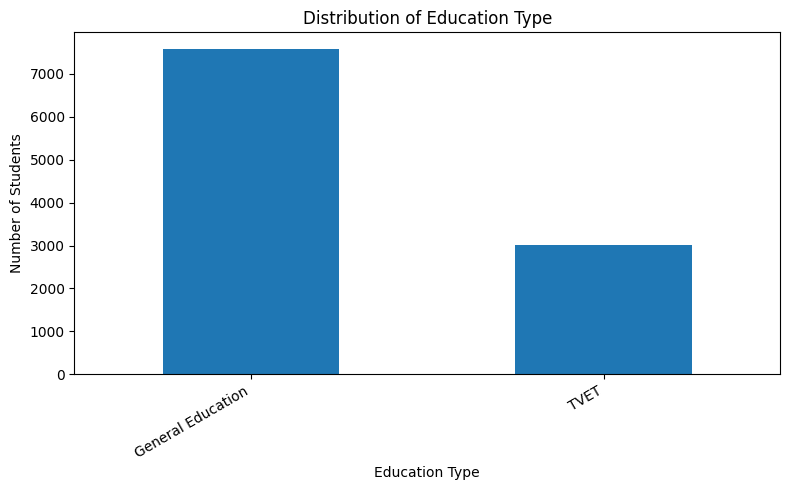

In [14]:
plt.figure(figsize=(8, 5))
df_clean["EducationType"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Type")
plt.xlabel("Education Type")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Top Pathways in the Dataset

This chart displays the top 10 academic or vocational pathways students are currently following. This gives us an overview of the most common educational tracks and helps in understanding the primary areas of student focus.


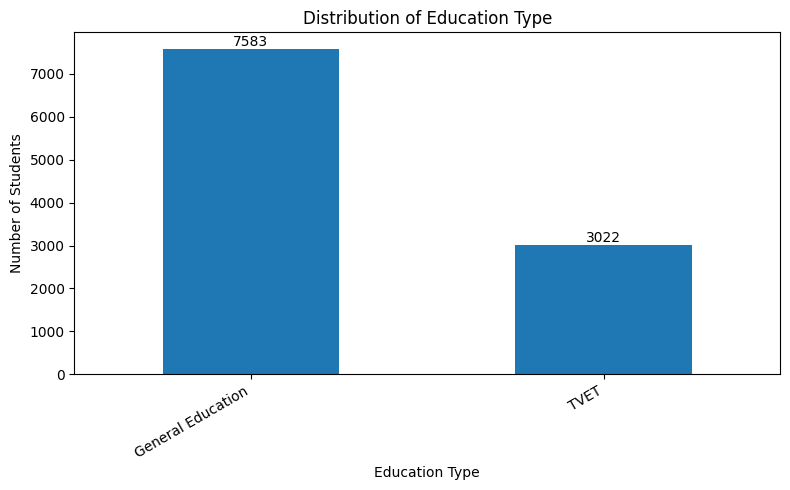

In [17]:
plt.figure(figsize=(8, 5))
ax = df_clean["EducationType"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Type")
plt.xlabel("Education Type")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

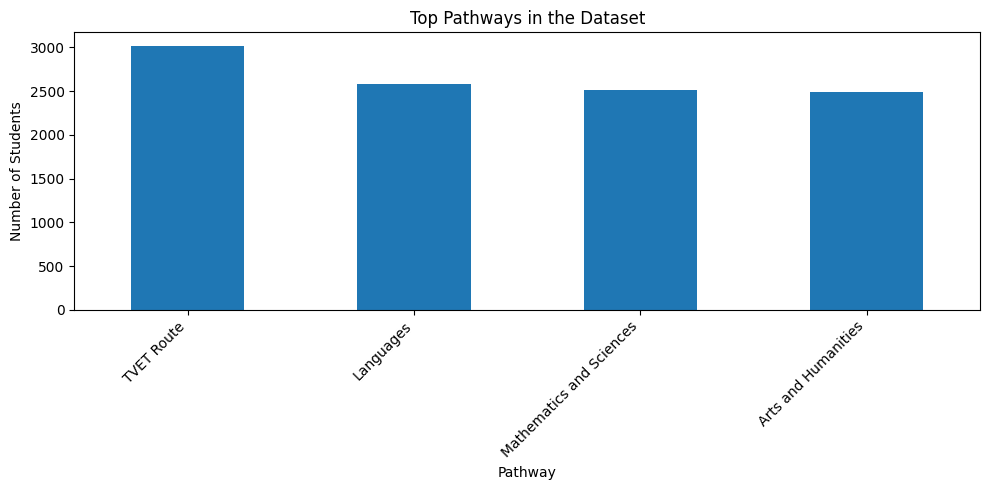

In [15]:
plt.figure(figsize=(10, 5))
df_clean["Pathway"].value_counts().head(10).plot(kind="bar")
plt.title("Top Pathways in the Dataset")
plt.xlabel("Pathway")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### **Top Recommended Program Categories**

This bar chart shows the distribution of the top 15 recommended university program categories. This visualization is key to understanding the target variable's class balance and identifying the most frequently recommended academic paths, which will be the basis for our prediction model.


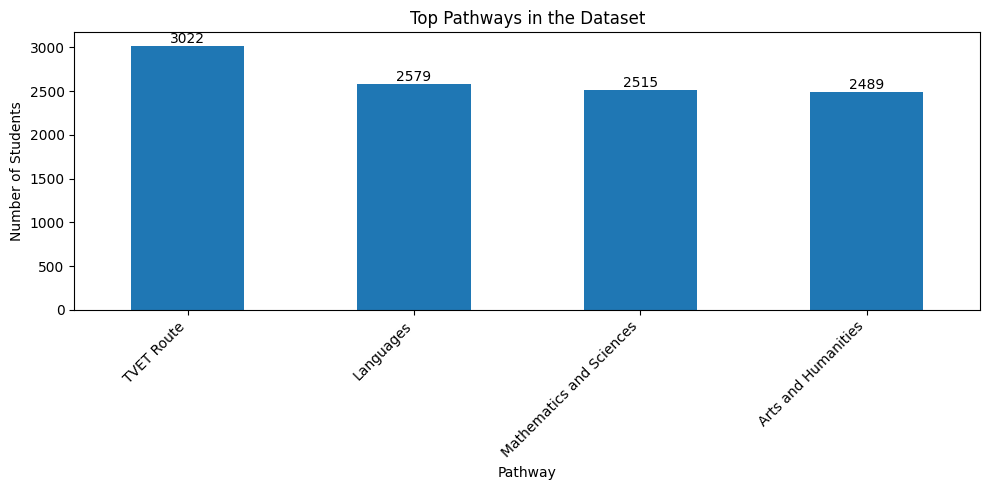

In [18]:
plt.figure(figsize=(10, 5))
ax = df_clean["Pathway"].value_counts().head(10).plot(kind="bar")
plt.title("Top Pathways in the Dataset")
plt.xlabel("Pathway")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

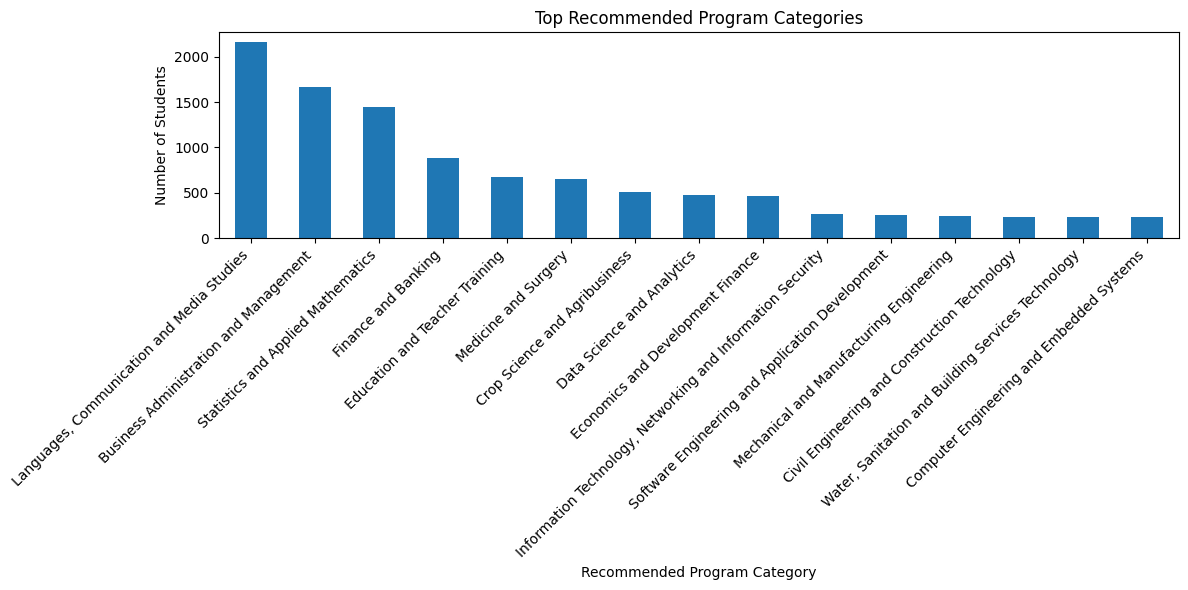

In [16]:
plt.figure(figsize=(12, 6))
df_clean[target_column].value_counts().head(15).plot(kind="bar")
plt.title("Top Recommended Program Categories")
plt.xlabel("Recommended Program Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

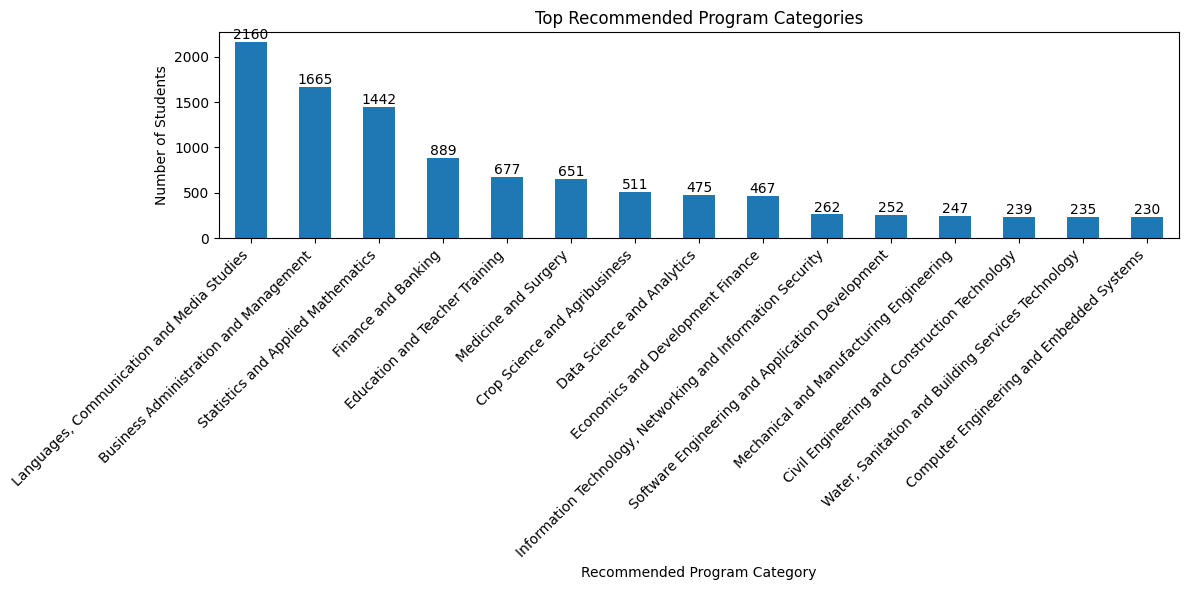

In [19]:
plt.figure(figsize=(12, 6))
ax = df_clean[target_column].value_counts().head(15).plot(kind="bar")
plt.title("Top Recommended Program Categories")
plt.xlabel("Recommended Program Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Leakage check and final modeling dataset**

In [20]:
leakage_columns = [
    "StudentID",
    "RecommendedProgram",
    "RecommendedProgram_simplified",
    "RecommendedProgram_grouped",
    "RecommendedProgramCategory",
    "RecommendedBridgeCourse",
    "AlternativePathway",
    "CareerDream"
]

print("Columns excluded to prevent data leakage:")
for col in leakage_columns:
    if col in df_clean.columns:
        print("-", col)

# Keep only rows with valid target values
df_model = df_clean.copy()
df_model[target_column] = df_model[target_column].fillna("General Academic Pathway").astype(str).str.strip()

df_model = df_model[df_model[target_column] != ""]
df_model = df_model[df_model[target_column].str.lower() != "nan"]

# Remove classes with only one sample because stratified train-test split cannot handle them
class_counts = df_model[target_column].value_counts()
rare_classes = class_counts[class_counts < 2].index.tolist()

if rare_classes:
    print("\nRare classes removed because they have fewer than 2 samples:")
    print(rare_classes)
    df_model = df_model[~df_model[target_column].isin(rare_classes)]

X = df_model[input_features].copy()
y = df_model[target_column].copy()

print("\nFinal modeling dataset shape:", df_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts())

Columns excluded to prevent data leakage:
- StudentID
- RecommendedProgram
- RecommendedProgramCategory
- RecommendedBridgeCourse
- AlternativePathway
- CareerDream

Final modeling dataset shape: (10605, 15)
X shape: (10605, 9)
y shape: (10605,)


,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster
0,General Education,Mathematics and Sciences,Stream 2,Physics,Geography,STEM Fields,60–69%,Advanced,Medicine & Health
1,General Education,Mathematics and Sciences,Stream 1,Physics,History,STEM Fields,90–100%,Beginner,Medicine & Health
2,General Education,Arts and Humanities,General Arts,Geography,Chemistry,Humanities & Business,80–89%,Beginner,Law & Governance
3,General Education,Arts and Humanities,General Arts,History,Physics,Humanities & Business,80–89%,Advanced,Law & Governance
4,General Education,Mathematics and Sciences,Stream 2,Biology,History,STEM Fields,80–89%,Advanced,Engineering and Technology


,count
RecommendedProgramCategory,
"Languages, Communication and Media Studies",2160
Business Administration and Management,1665
Statistics and Applied Mathematics,1442
Finance and Banking,889
Education and Teacher Training,677
Medicine and Surgery,651
Crop Science and Agribusiness,511
Data Science and Analytics,475
Economics and Development Finance,467


# **7. Train-Test Split and Target Encoding**

The target labels are encoded using `LabelEncoder` because machine learning models work better with numerical class labels. The original class names are saved so that predictions can be converted back into readable program categories.

**Split data**

In [21]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Stratification is used to preserve class distribution in train and test sets
stratify_target = y_encoded if pd.Series(y_encoded).value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_target
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of target classes:", len(label_encoder.classes_))

print("\nTarget classes:")
for class_name in label_encoder.classes_:
    print("-", class_name)

Training shape: (8484, 9)
Testing shape: (2121, 9)
Number of target classes: 16

Target classes:
- Biotechnology and Applied Biosciences
- Business Administration and Management
- Civil Engineering and Construction Technology
- Computer Engineering and Embedded Systems
- Crop Science and Agribusiness
- Data Science and Analytics
- Economics and Development Finance
- Education and Teacher Training
- Finance and Banking
- Information Technology, Networking and Information Security
- Languages, Communication and Media Studies
- Mechanical and Manufacturing Engineering
- Medicine and Surgery
- Software Engineering and Application Development
- Statistics and Applied Mathematics
- Water, Sanitation and Building Services Technology


# **8. Model Training and Comparison**

This section trains and compares multiple models aligned with the research proposal:

- Decision Tree
- Random Forest
- XGBoost
- Logistic Regression
- Support Vector Machine

The best model is selected using macro F1-score first, then accuracy. Macro F1-score is important because it evaluates performance across all program categories, not only the largest classes.

**Build preprocessing and models**

In [22]:
# One-hot encoding for categorical input features
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical_features", one_hot_encoder, input_features)
    ],
    remainder="drop"
)

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=None,
        min_samples_split=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Support Vector Machine": LinearSVC(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_iter=5000
    )
}

# Add XGBoost only if it is installed
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )

    print("XGBoost is available and has been added.")
except Exception as e:
    print("XGBoost is not available in this environment. The notebook will continue without it.")
    print("Reason:", e)

model_pipelines = {}

for model_name, model in models.items():
    model_pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

print("Models prepared:")
for model_name in model_pipelines.keys():
    print("-", model_name)

XGBoost is available and has been added.
Models prepared:
- Decision Tree
- Random Forest
- Extra Trees
- Logistic Regression
- Support Vector Machine
- XGBoost


**Train and compare models**

In [23]:
results = []
trained_models = {}

for model_name, pipeline in model_pipelines.items():
    print(f"\nTraining {model_name}...")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_test, y_pred, average="micro", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1-score": f1_macro,
        "Micro F1-score": f1_micro
    })

    trained_models[model_name] = pipeline

    print(f"{model_name} completed.")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["Macro F1-score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(results_df)


Training Decision Tree...
Decision Tree completed.
Accuracy: 0.9463
Macro F1-score: 0.9290

Training Random Forest...
Random Forest completed.
Accuracy: 0.9510
Macro F1-score: 0.9271

Training Extra Trees...
Extra Trees completed.
Accuracy: 0.9491
Macro F1-score: 0.9280

Training Logistic Regression...
Logistic Regression completed.
Accuracy: 0.9260
Macro F1-score: 0.9278

Training Support Vector Machine...
Support Vector Machine completed.
Accuracy: 0.9425
Macro F1-score: 0.9389

Training XGBoost...
XGBoost completed.
Accuracy: 0.9514
Macro F1-score: 0.9214


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Micro F1-score
0,Support Vector Machine,0.942480,0.934367,0.961742,0.938949,0.942480
1,Decision Tree,0.946252,0.926681,0.932060,0.928976,0.946252
2,Extra Trees,0.949081,0.927264,0.928992,0.928035,0.949081
3,Logistic Regression,0.925978,0.929788,0.965163,0.927847,0.925978
4,Random Forest,0.950967,0.927875,0.926799,0.927115,0.950967
5,XGBoost,0.951438,0.925000,0.920016,0.921426,0.951438


# **9. Best Model Selection**

The best model is selected based on macro F1-score and accuracy. This ensures the chosen model performs well across different program categories and is not only strong on the majority class.

In [24]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Best model selected: Support Vector Machine

Classification Report:
                                                             precision    recall  f1-score   support

                      Biotechnology and Applied Biosciences       0.37      0.93      0.53        41
                     Business Administration and Management       1.00      1.00      1.00       333
              Civil Engineering and Construction Technology       1.00      1.00      1.00        48
                  Computer Engineering and Embedded Systems       1.00      1.00      1.00        46
                              Crop Science and Agribusiness       1.00      1.00      1.00       102
                                 Data Science and Analytics       0.68      0.81      0.74        95
                          Economics and Development Finance       1.00      1.00      1.00        93
                             Education and Teacher Training       1.00      1.00      1.00       135
                      

**Confusion matrix**

<Figure size 1200x1000 with 0 Axes>

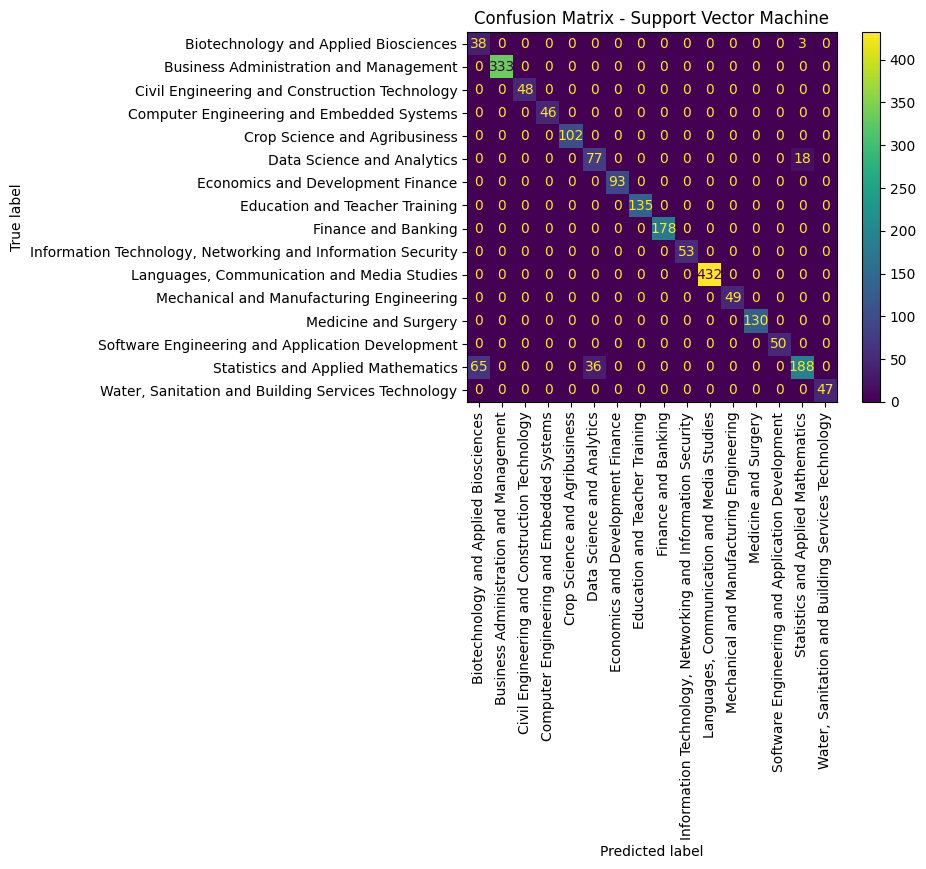

In [25]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(xticks_rotation=90, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

# **10. Explainability Through Feature Importance**

The research proposal emphasizes explainability. This section shows which student-profile features influence the model most.

For tree-based models, the notebook uses feature importance. For linear models, it uses the magnitude of model coefficients. This helps students and advisors understand the reasoning behind recommendations.

,Encoded Feature,Importance
58,CareerCluster_Business & Finance,0.298662
69,CareerCluster_Medicine & Health,0.226760
61,CareerCluster_Education,0.203460
24,BestSubject_Economics,0.203223
21,Stream_or_Trade_Welding / Mechanical,0.202469
14,Stream_or_Trade_Masonry / Construction,0.202423
9,Stream_or_Trade_Domestic Plumbing / Water,0.202408
10,Stream_or_Trade_Electrical Technology,0.202328
0,EducationType_General Education,0.200078
16,Stream_or_Trade_Networking and Telecommunication,0.189352


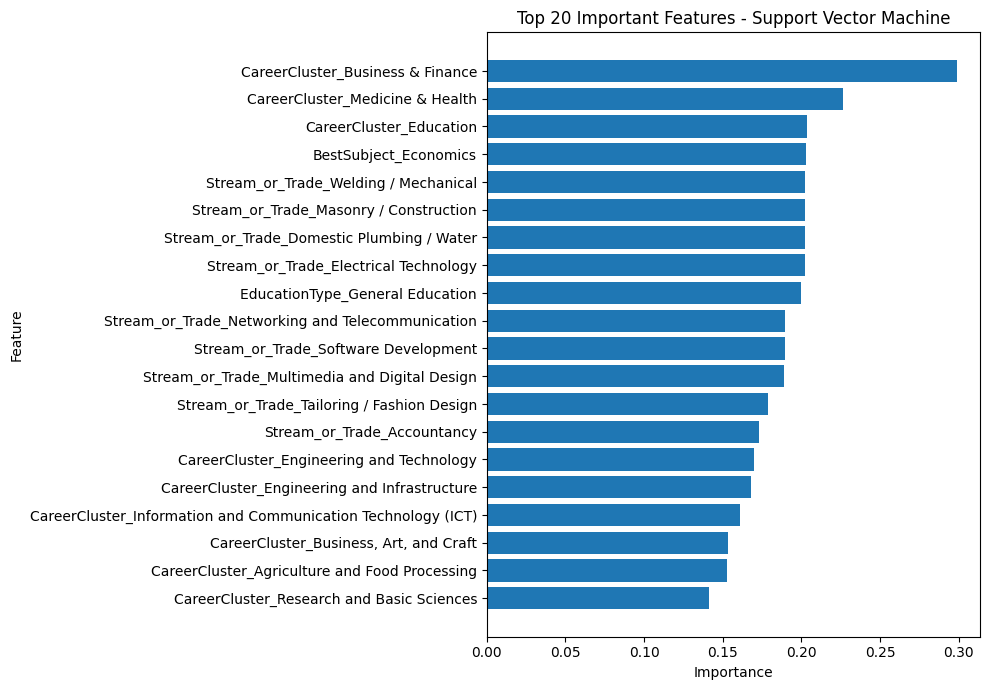

In [26]:
def get_feature_names_from_pipeline(pipeline, input_features):
    preprocessor = pipeline.named_steps["preprocessor"]
    encoder = preprocessor.named_transformers_["categorical_features"]

    try:
        feature_names = encoder.get_feature_names_out(input_features)
    except Exception:
        feature_names = encoder.get_feature_names(input_features)

    return np.array(feature_names)

def extract_feature_importance(pipeline, input_features):
    classifier = pipeline.named_steps["classifier"]
    feature_names = get_feature_names_from_pipeline(pipeline, input_features)

    if hasattr(classifier, "feature_importances_"):
        importance_values = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        importance_values = np.mean(np.abs(classifier.coef_), axis=0)
    else:
        return None

    importance_df = pd.DataFrame({
        "Encoded Feature": feature_names,
        "Importance": importance_values
    }).sort_values(by="Importance", ascending=False)

    return importance_df

importance_df = extract_feature_importance(best_model, input_features)

if importance_df is not None:
    display(importance_df.head(20))

    plt.figure(figsize=(10, 7))
    top_features = importance_df.head(20).sort_values(by="Importance", ascending=True)
    plt.barh(top_features["Encoded Feature"], top_features["Importance"])
    plt.title(f"Top 20 Important Features - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not directly available for this model.")

**Aggregate importance by original input feature**

,Original Feature,Total Importance
8,CareerCluster,2.515591
2,Stream_or_Trade,2.285262
3,BestSubject,0.767400
5,InterestArea,0.379127
1,Pathway,0.379127
4,WeakestSubject,0.343811
6,AverageScoreRange,0.319082
0,EducationType,0.294733
7,DigitalSkillLevel,0.294733


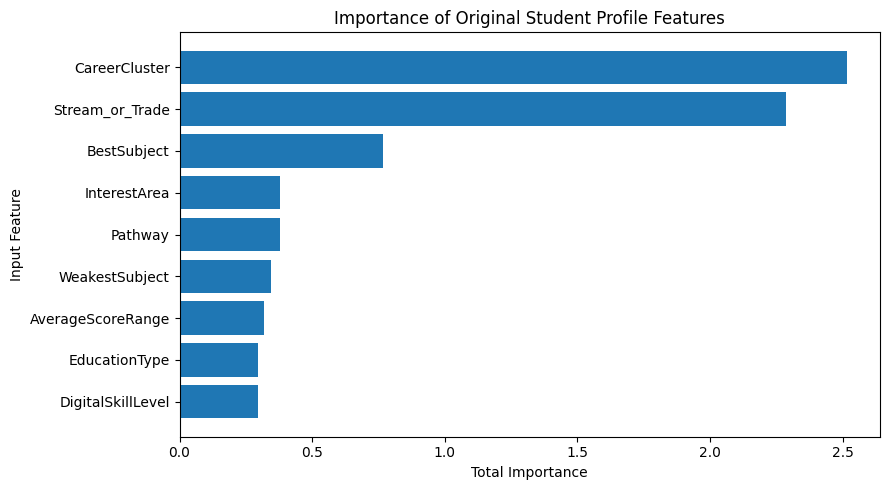

In [27]:
if importance_df is not None:
    original_feature_importance = []

    for original_feature in input_features:
        matching_rows = importance_df[
            importance_df["Encoded Feature"].str.contains(original_feature, regex=False)
        ]

        total_importance = matching_rows["Importance"].sum()

        original_feature_importance.append({
            "Original Feature": original_feature,
            "Total Importance": total_importance
        })

    original_importance_df = pd.DataFrame(original_feature_importance)
    original_importance_df = original_importance_df.sort_values(
        by="Total Importance",
        ascending=False
    )

    display(original_importance_df)

    plt.figure(figsize=(9, 5))
    plot_df = original_importance_df.sort_values(by="Total Importance", ascending=True)
    plt.barh(plot_df["Original Feature"], plot_df["Total Importance"])
    plt.title("Importance of Original Student Profile Features")
    plt.xlabel("Total Importance")
    plt.ylabel("Input Feature")
    plt.tight_layout()
    plt.show()

# **11. Final Model Training on the Full Clean Dataset**

After selecting the best model using the test set, the final model is retrained using the full cleaned dataset. This allows the final saved model to learn from all available records before being used in the Streamlit or FastAPI system.

In [28]:
print("Retraining final model on the full clean dataset...")
print("Final model type:", best_model_name)

final_pipeline = clone(model_pipelines[best_model_name])
final_pipeline.fit(X, y_encoded)

print("Final model retrained successfully.")

Retraining final model on the full clean dataset...
Final model type: Support Vector Machine
Final model retrained successfully.


## **12. Save the Trained Model and Supporting Artifacts**

This section saves the `final_pipeline` (best model), `label_encoder`, `input_features`, and the `PROGRAM_CATEGORY_TO_BRIDGE_COURSE` and `PROGRAM_CATEGORY_TO_ALTERNATIVE_PATHWAY` maps. These artifacts will be used to deploy the recommendation system.


In [67]:
model_dir = Path("/content/drive/MyDrive/academic pathway/models")
model_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_file_name = f"academic_pathway_model_{timestamp}.joblib"
model_save_path = model_dir / model_file_name

artifact = {
    "model": final_pipeline,
    "label_encoder": label_encoder,
    "input_features": input_features,
    "bridge_course_map": PROGRAM_CATEGORY_TO_BRIDGE_COURSE,
    "alternative_pathway_map": PROGRAM_CATEGORY_TO_ALTERNATIVE_PATHWAY,
    "timestamp": timestamp,
    "model_name": best_model_name
}

joblib.dump(artifact, model_save_path)

print(f"Model and artifacts saved to: {model_save_path}")

Model and artifacts saved to: /content/drive/MyDrive/academic pathway/models/academic_pathway_model_20260708_093256.joblib


# **12. Student Recommendation Test**

This section tests the final model using one sample student profile. The output includes:

1. Predicted university program category
2. Recommended bridge course
3. Alternative academic pathway
4. A simple explanation based on important features

In [50]:
def recommend_student_profile(student_profile):
    """
    Hybrid recommendation function:
    1. First applies rule-based eligibility logic.
    2. If no strong rule is found, it uses the trained ML model.
    3. Then maps the program category to a bridge course.
    4. Then provides an alternative pathway and explanation.
    """

    # Step 1: Try rule-based recommendation first
    rule_based_category = rule_based_program_recommendation(student_profile)

    if rule_based_category is not None:
        predicted_category = rule_based_category
        recommendation_source = "Rule-based eligibility filter"
    else:
        # Step 2: If no rule applies, use the ML model
        student_df = pd.DataFrame([student_profile])

        for col in input_features:
            if col not in student_df.columns:
                student_df[col] = "Unknown"

        student_df = student_df[input_features]

        encoded_prediction = final_pipeline.predict(student_df)[0]
        predicted_category = label_encoder.inverse_transform([encoded_prediction])[0]
        recommendation_source = "Machine learning model"

    # Step 3: Bridge course mapping
    recommended_bridge_course = PROGRAM_CATEGORY_TO_BRIDGE_COURSE.get(
        predicted_category,
        "Academic Writing, Study Skills, Digital Literacy, and Career Readiness"
    )

    # Step 4: Alternative pathway mapping
    alternative_pathway = PROGRAM_CATEGORY_TO_ALTERNATIVE_PATHWAY.get(
        predicted_category,
        "Related diploma, certificate, or foundation pathway"
    )

    # Step 5: Explanation
    explanation = (
        f"The system recommended '{predicted_category}' using the {recommendation_source}. "
        f"The decision considered the student's education type ({student_profile.get('EducationType', 'Unknown')}), "
        f"pathway ({student_profile.get('Pathway', 'Unknown')}), "
        f"stream or trade ({student_profile.get('Stream_or_Trade', 'Unknown')}), "
        f"best subject ({student_profile.get('BestSubject', 'Unknown')}), "
        f"weakest subject ({student_profile.get('WeakestSubject', 'Unknown')}), "
        f"interest area ({student_profile.get('InterestArea', 'Unknown')}), "
        f"average score range ({student_profile.get('AverageScoreRange', 'Unknown')}), "
        f"digital skill level ({student_profile.get('DigitalSkillLevel', 'Unknown')}), "
        f"and career cluster ({student_profile.get('CareerCluster', 'Unknown')})."
    )

    return {
        "Recommended Program Category": predicted_category,
        "Recommended Bridge Course": recommended_bridge_course,
        "Alternative Pathway": alternative_pathway,
        "Recommendation Source": recommendation_source,
        "Explanation": explanation
    }

In [63]:
import re

def has_term(text, terms):
    """
    Checks full words/phrases safely.
    This prevents mistakes such as detecting 'media' inside 'intermediate'.
    """
    text = str(text).lower()
    return any(re.search(rf"\b{re.escape(term.lower())}\b", text) for term in terms)


def rule_based_program_recommendation(student_profile):
    """
    Rule-based eligibility layer.

    This function handles strong academic cases before the ML model is used.
    It gives priority to interest area, career cluster, and TVET trade.
    """

    education_type = str(student_profile.get("EducationType", "")).lower()
    pathway = str(student_profile.get("Pathway", "")).lower()
    stream_or_trade = str(student_profile.get("Stream_or_Trade", "")).lower()
    best_subject = str(student_profile.get("BestSubject", "")).lower()
    weakest_subject = str(student_profile.get("WeakestSubject", "")).lower()
    interest_area = str(student_profile.get("InterestArea", "")).lower()
    career_cluster = str(student_profile.get("CareerCluster", "")).lower()
    digital_skill = str(student_profile.get("DigitalSkillLevel", "")).lower()

    combined = " ".join([
        education_type,
        pathway,
        stream_or_trade,
        best_subject,
        weakest_subject,
        interest_area,
        career_cluster,
        digital_skill
    ])

    combined = combined.replace("machine leraning", "machine learning")
    combined = combined.replace("machin learning", "machine learning")
    combined = combined.replace("data scince", "data science")
    combined = combined.replace("maths", "mathematics")

    # 1. TVET and practical trade rules
    if has_term(combined, ["hospitality", "culinary", "food and beverage", "hotel"]):
        return "Hospitality Management and Food and Beverage Services"

    if has_term(combined, ["tourism", "travel"]):
        return "Tourism and Travel Management"

    if has_term(combined, ["fashion", "garment", "textile"]):
        return "Fashion Design and Garment Production"

    if has_term(combined, ["multimedia", "graphic design", "digital media"]):
        return "Multimedia, Graphic Design and Digital Media Production"

    if has_term(combined, ["welding", "fabrication"]):
        return "Mechanical Fabrication and Welding Technology"

    if has_term(combined, ["construction", "infrastructure", "civil"]):
        return "Civil Engineering and Construction Technology"

    # 2. Health and medicine rules
    if has_term(combined, ["nursing"]):
        return "Nursing and Midwifery"

    if has_term(combined, ["medicine", "doctor", "medical"]):
        if has_term(best_subject, ["chemistry", "biology"]) or "mathematics and sciences" in pathway:
            return "Medicine and Surgery"

    if has_term(combined, ["pharmacy", "pharmaceutical"]):
        return "Pharmacy and Pharmaceutical Sciences"

    if has_term(combined, ["biomedical", "laboratory"]):
        return "Biomedical Laboratory Sciences"

    # 3. AI, machine learning, data and technology rules
    if has_term(combined, [
        "machine learning",
        "artificial intelligence",
        "ai",
        "data science",
        "data analytics",
        "analytics"
    ]) or "data" in career_cluster:
        return "Data Science and Analytics"

    if has_term(combined, ["statistics", "applied mathematics"]):
        return "Statistics and Applied Mathematics"

    if has_term(combined, ["software", "programming", "application development", "web development"]):
        return "Software Engineering and Application Development"

    if has_term(combined, ["computer science", "information systems"]):
        return "Computer Science and Information Systems"

    if has_term(combined, ["network", "cyber", "security"]):
        return "Information Technology, Networking and Information Security"

    if has_term(combined, ["system administration", "it support"]):
        return "Information Technology and Systems Administration"

    if has_term(combined, ["computer engineering", "embedded", "electronics"]):
        return "Computer Engineering and Embedded Systems"

    if has_term(interest_area, ["technology"]) and has_term(best_subject, ["mathematics"]):
        return "Data Science and Analytics"

    # 4. Business and finance rules
    # This comes before media/language rules to prevent finance cases from being misclassified.
    if has_term(combined, ["finance", "banking"]):
        return "Finance and Banking"

    if has_term(combined, ["accounting"]):
        return "Accounting and Finance"

    if has_term(combined, ["economics", "development finance"]):
        return "Economics and Development Finance"

    if has_term(combined, ["business", "management", "entrepreneurship"]):
        return "Business Administration and Management"

    # 5. Engineering and technical services
    if has_term(combined, ["electrical installation"]):
        return "Electrical Technology and Power Systems"

    if has_term(combined, ["electrical", "power", "energy"]):
        return "Electrical Engineering and Power Systems"

    if has_term(combined, ["mechanical", "manufacturing", "automotive"]):
        return "Mechanical and Manufacturing Engineering"

    if has_term(combined, ["water", "sanitation", "plumbing"]):
        return "Water, Sanitation and Building Services Technology"

    # 6. Agriculture, food and environment
    if has_term(combined, ["agriculture", "agribusiness", "crop"]):
        return "Crop Science and Agribusiness"

    if has_term(combined, ["food science", "food processing", "nutrition"]):
        return "Food Science and Processing Technology"

    if has_term(combined, ["environment", "sustainability", "climate"]):
        return "Environmental Science and Sustainability"

    if has_term(combined, ["gis", "geography"]):
        return "Geography, GIS and Environmental Planning"

    if has_term(combined, ["urban", "regional planning"]):
        return "Urban and Regional Planning"

    # 7. Law, humanities and languages
    if has_term(combined, ["law", "legal"]):
        return "Law and Legal Studies"

    if has_term(combined, ["governance", "public administration"]):
        return "Public Administration and Governance"

    if has_term(combined, ["international relations", "diplomacy"]):
        return "International Relations and Diplomacy"

    if has_term(combined, ["psychology", "counselling", "counseling"]):
        return "Psychology and Counselling Studies"

    if has_term(combined, ["sociology", "social sciences"]):
        return "Sociology and Social Sciences"

    if has_term(combined, ["social work", "community development"]):
        return "Social Work and Community Development"

    if has_term(combined, ["development studies"]):
        return "Development Studies and Community Development"

    if has_term(combined, ["translation", "interpretation"]):
        return "Translation and Interpretation"

    if has_term(combined, ["english", "literature", "language"]):
        return "English, Literature and Language Studies"

    if has_term(combined, ["journalism", "media studies"]):
        return "Journalism and Media Studies"

    if has_term(combined, ["communication", "public relations"]):
        return "Communication and Public Relations"

    if has_term(combined, ["education", "teaching", "teacher"]):
        if has_term(combined, ["language"]):
            return "Education in Languages"
        return "Education in Arts and Humanities"

    return None

**Test sample prediction**

In [64]:
sample_student = {
    "EducationType": "General Education",
    "Pathway": "Arts and Humanities",
    "Stream_or_Trade": "Arts and Humanities",
    "BestSubject": "History",
    "WeakestSubject": "Literature",
    "InterestArea": "Technology",
    "AverageScoreRange": "70–79%",
    "DigitalSkillLevel": "Intermediate",
    "CareerCluster": "Data science"
}

sample_recommendation = recommend_student_profile(sample_student)

print("Sample Student Recommendation")
print("-----------------------------")

for key, value in sample_recommendation.items():
    print(f"{key}: {value}")

Sample Student Recommendation
-----------------------------
Recommended Program Category: Data Science and Analytics
Recommended Bridge Course: Mathematics for Data, Statistics, Python, Excel, and SQL Basics
Alternative Pathway: Advanced Diploma (A1) Route in matching discipline
Recommendation Source: Rule-based eligibility filter
Explanation: The system recommended 'Data Science and Analytics' using the Rule-based eligibility filter. The decision considered the student's education type (General Education), pathway (Arts and Humanities), stream or trade (Arts and Humanities), best subject (History), weakest subject (Literature), interest area (Technology), average score range (70–79%), digital skill level (Intermediate), and career cluster (Data science).


In [65]:
test_students = [
    {
        "EducationType": "General Education",
        "Pathway": "Arts and Humanities",
        "Stream_or_Trade": "Arts and Humanities",
        "BestSubject": "History",
        "WeakestSubject": "Literature",
        "InterestArea": "Law",
        "AverageScoreRange": "70–79%",
        "DigitalSkillLevel": "Intermediate",
        "CareerCluster": "Law"
    },
    {
        "EducationType": "General Education",
        "Pathway": "Mathematics and Sciences",
        "Stream_or_Trade": "Stream 1",
        "BestSubject": "Chemistry",
        "WeakestSubject": "Mathematics",
        "InterestArea": "Nursing",
        "AverageScoreRange": "70–79%",
        "DigitalSkillLevel": "Intermediate",
        "CareerCluster": "Medicine"
    },
    {
        "EducationType": "General Education",
        "Pathway": "Mathematics and Sciences",
        "Stream_or_Trade": "Stream 2",
        "BestSubject": "Mathematics",
        "WeakestSubject": "Geography",
        "InterestArea": "Technology",
        "AverageScoreRange": "70–79%",
        "DigitalSkillLevel": "Intermediate",
        "CareerCluster": "Data science"
    },
    {
        "EducationType": "General Education",
        "Pathway": "Mathematics and Sciences",
        "Stream_or_Trade": "Stream 2",
        "BestSubject": "Economics",
        "WeakestSubject": "Physics",
        "InterestArea": "Finance",
        "AverageScoreRange": "70–79%",
        "DigitalSkillLevel": "Intermediate",
        "CareerCluster": "Finance"
    },
    {
        "EducationType": "TVET",
        "Pathway": "TVET",
        "Stream_or_Trade": "Hospitality",
        "BestSubject": "Entrepreneurship",
        "WeakestSubject": "Mathematics",
        "InterestArea": "Hospitality",
        "AverageScoreRange": "60–69%",
        "DigitalSkillLevel": "Beginner",
        "CareerCluster": "Hospitality"
    },
    {
        "EducationType": "TVET",
        "Pathway": "TVET",
        "Stream_or_Trade": "Software development",
        "BestSubject": "Machine leraning",
        "WeakestSubject": "Frontend",
        "InterestArea": "Machine learning engineering",
        "AverageScoreRange": "60–69%",
        "DigitalSkillLevel": "Beginner",
        "CareerCluster": "AI"
    },
    {
        "EducationType": "TVET",
        "Pathway": "TVET",
        "Stream_or_Trade": "Construction",
        "BestSubject": "Maths",
        "WeakestSubject": "Entrepreneurship",
        "InterestArea": "construction",
        "AverageScoreRange": "60–69%",
        "DigitalSkillLevel": "Beginner",
        "CareerCluster": "Infrastructure"
    }
]

test_results = []

for i, student in enumerate(test_students, start=1):
    result = recommend_student_profile(student)

    test_results.append({
        "Test Case": i,
        "Education Type": student["EducationType"],
        "Pathway": student["Pathway"],
        "Best Subject": student["BestSubject"],
        "Interest Area": student["InterestArea"],
        "Career Cluster": student["CareerCluster"],
        "Recommended Program Category": result["Recommended Program Category"],
        "Recommended Bridge Course": result["Recommended Bridge Course"],
        "Recommendation Source": result["Recommendation Source"]
    })

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

,Test Case,Education Type,Pathway,Best Subject,Interest Area,Career Cluster,Recommended Program Category,Recommended Bridge Course,Recommendation Source
0,1,General Education,Arts and Humanities,History,Law,Law,Law and Legal Studies,"Academic Writing, Critical Thinking, Governanc...",Rule-based eligibility filter
1,2,General Education,Mathematics and Sciences,Chemistry,Nursing,Medicine,Nursing and Midwifery,"Human Biology, Patient Care Basics, and Health...",Rule-based eligibility filter
2,3,General Education,Mathematics and Sciences,Mathematics,Technology,Data science,Data Science and Analytics,"Mathematics for Data, Statistics, Python, Exce...",Rule-based eligibility filter
3,4,General Education,Mathematics and Sciences,Economics,Finance,Finance,Finance and Banking,"Business Mathematics, Financial Literacy, Bank...",Rule-based eligibility filter
4,5,TVET,TVET,Entrepreneurship,Hospitality,Hospitality,Hospitality Management and Food and Beverage S...,"Food and Beverage Service, Customer Care, Hygi...",Rule-based eligibility filter
5,6,TVET,TVET,Machine leraning,Machine learning engineering,AI,Data Science and Analytics,"Mathematics for Data, Statistics, Python, Exce...",Rule-based eligibility filter
6,7,TVET,TVET,Maths,construction,Infrastructure,Civil Engineering and Construction Technology,"Mathematics, Physics, Technical Drawing, and C...",Rule-based eligibility filter


# **14. Reload Saved Model Test**

This section confirms that the saved model can be loaded again and used for prediction. This is important because the saved file will later be connected to the Streamlit dashboard or FastAPI backend.

In [69]:
loaded_artifact = joblib.load(model_save_path)

loaded_model = loaded_artifact["model"]
loaded_label_encoder = loaded_artifact["label_encoder"]
loaded_input_features = loaded_artifact["input_features"]
loaded_bridge_course_map = loaded_artifact["bridge_course_map"]
loaded_alternative_pathway_map = loaded_artifact["alternative_pathway_map"]

test_df = pd.DataFrame([sample_student])[loaded_input_features]

loaded_prediction_encoded = loaded_model.predict(test_df)[0]
loaded_prediction_category = loaded_label_encoder.inverse_transform([loaded_prediction_encoded])[0]

print("Reload test successful.")
print("Predicted Program Category:", loaded_prediction_category)
print("Recommended Bridge Course:", loaded_bridge_course_map.get(loaded_prediction_category))
print("Alternative Pathway:", loaded_alternative_pathway_map.get(loaded_prediction_category, "Related diploma, certificate, or foundation pathway"))

Reload test successful.
Predicted Program Category: Business Administration and Management
Recommended Bridge Course: Management Principles, Entrepreneurship, Business Communication, and Excel
Alternative Pathway: Advanced Diploma (A1) Route in matching discipline


In [68]:
loaded_artifact = joblib.load(model_save_path)

loaded_model = loaded_artifact["model"]
loaded_label_encoder = loaded_artifact["label_encoder"]
loaded_input_features = loaded_artifact["input_features"]
loaded_bridge_course_map = loaded_artifact["bridge_course_map"]
loaded_alternative_pathway_map = loaded_artifact["alternative_pathway_map"]

test_df = pd.DataFrame([sample_student])[loaded_input_features]

loaded_prediction_encoded = loaded_model.predict(test_df)[0]
loaded_prediction_category = loaded_label_encoder.inverse_transform([loaded_prediction_encoded])[0]

print("Reload test successful.")
print("Predicted Program Category:", loaded_prediction_category)
print("Recommended Bridge Course:", loaded_bridge_course_map.get(loaded_prediction_category))
print("Alternative Pathway:", loaded_alternative_pathway_map.get(loaded_prediction_category, "Related diploma, certificate, or foundation pathway"))

Reload test successful.
Predicted Program Category: Business Administration and Management
Recommended Bridge Course: Management Principles, Entrepreneurship, Business Communication, and Excel
Alternative Pathway: Advanced Diploma (A1) Route in matching discipline


# **15. Final Notebook Summary**

This notebook successfully prepared the dataset, controlled data leakage, trained and compared several machine learning models, selected the best-performing model, added an explainability layer, and saved the final model artifact.

The final saved model can now be connected to the Streamlit dashboard or FastAPI backend. The model predicts the recommended university program category, while the bridge-course and alternative-pathway outputs are generated through a transparent mapping layer.

This supports the project objective of building an explainable academic pathway and bridge course recommendation system for Rwandan students.